In [1]:
from scipy.sparse import coo_array, diags

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import anndata as ad

import scanpy as sc
sc.settings.figdir = './results/'



In [ ]:
# download FAFB v783 data (conections ,neurons, classification) from flywire.ai and put it in ../data/flywire_v783/
data_path = "../data/flywire_v783/"

# --------- Load in data and format it ---------------
traced_neurons = pd.read_csv(data_path + "classification.csv")
traced_neurons['bodyId'] = traced_neurons['root_id']

connections = pd.read_csv(data_path + "connections.csv")
connections['weight'] = connections['syn_count']
# make names align with hemibrain so I can easily reuse code
connections['bodyId_pre'] = connections['pre_root_id']
connections['bodyId_post'] = connections['post_root_id']

bodyId_to_idx = {}
idx_to_bodyId = {}
for i, bodyId in enumerate(traced_neurons['bodyId']):
    bodyId_to_idx[bodyId] = i
    idx_to_bodyId[i] = bodyId

def convert_bodyId_to_idx(a):
    return a.apply(lambda x: bodyId_to_idx[x])
traced_neurons['idx'] = convert_bodyId_to_idx(traced_neurons['bodyId'])
connections['idx_pre'] = convert_bodyId_to_idx(connections['bodyId_pre'])
connections['idx_post'] = convert_bodyId_to_idx(connections['bodyId_post'])


# In FAFB there are multiple connections with the pre and post id, with different neuropils. Here, we some across those before screening for connections with at least 10 synapses.
connections = connections.groupby(['pre_root_id', 'bodyId_pre', 'post_root_id', 'bodyId_post','idx_pre', 'idx_post']).agg('sum').reset_index()
# remove connections with less than 10 synapses, as they are likely to be noise
connections = connections[connections.weight>=10]

# I use the neurotransmitter assigned to the whole cell, rather than connection-specific assignments.
nts = pd.read_csv(data_path + "neurons.csv")
connections = connections.merge(nts[['root_id', 'nt_type']], left_on='pre_root_id', right_on = 'root_id', suffixes=('','_overall')).drop(columns=['root_id']).copy()




In [3]:
# fill empty hemibrain types with cell type and then root id
traced_neurons['hemibrain_type'] = traced_neurons['hemibrain_type'].fillna(traced_neurons['cell_type'])
traced_neurons['hemibrain_type'] = traced_neurons['hemibrain_type'].fillna(traced_neurons['root_id'])

 # subtypes of LAL144 have different connectivity patterns w.r.t. MDN
traced_neurons.loc[traced_neurons['hemibrain_type']=='LAL144', 'hemibrain_type'] = traced_neurons[traced_neurons['hemibrain_type']=='LAL144']['cell_type']

MDN and MBON neurons

In [4]:
mdn_neurons_indices = list(traced_neurons[traced_neurons.hemibrain_type=='MDN']['idx'])
mbon_traced_neurons = traced_neurons[( traced_neurons['class']=='MBON')].copy()
mbon_indices = mbon_traced_neurons['idx'].unique()
mbon_roots = mbon_traced_neurons['root_id'].unique()


## Neurotransmitter assigments and weight matrices

 there are five neurons with no neurotransmitter assignments -- an MBON05, 03, 32, and two MBON10s. All the other neurons of those types are GLUT/ GABA which are thought to be inhibitory, so I will assign the nans to be PUTATIVE_NEG.

 

In [5]:
# Looking at the mbons without nts assigned

mbon_nts = nts[nts.root_id.apply(lambda x: x in mbon_roots)]
    
ntsless_mbons = list(mbon_nts[mbon_nts.nt_type.isna()].root_id)
display(traced_neurons[traced_neurons.root_id.apply(lambda x: x in ntsless_mbons)])

connections.loc[connections.pre_root_id.apply(lambda x: x in ntsless_mbons),'nt_type'] = 'PUTATIVE_NEG'
connections['sign'] = connections.apply(lambda x: (-1 if x.nt_type in ['GABA', 'GLUT', 'PUTATIVE_NEG'] else (1 if x.nt_type=='ACH' else 0)), axis = 1)

# a matrix per neurotransmitter
nts_connections_mats = {}

for name, group in connections.groupby('nt_type', dropna=False):
    if type(name) == float:
        name = 'nan'
    nts_connections_mats[name] =  coo_array((group['weight'], (group['idx_post'], group['idx_pre'])), shape=(len(traced_neurons),len(traced_neurons))).tocsr() # pre are the columsn, post are the rows


,root_id,flow,super_class,class,sub_class,cell_type,hemibrain_type,hemilineage,side,nerve,bodyId,idx
7679,720575940621164720,intrinsic,central,MBON,NaN,NaN,MBON05,putative_primary,left,NaN,720575940621164720,7679
7817,720575940632118343,intrinsic,central,MBON,NaN,NaN,MBON10,EBa1,left,NaN,720575940632118343,7817
16065,720575940624694503,intrinsic,central,MBON,NaN,NaN,MBON03,putative_primary,left,NaN,720575940624694503,16065
98094,720575940633209647,intrinsic,central,MBON,NaN,NaN,MBON10,EBa1,left,NaN,720575940633209647,98094
127437,720575940638526278,intrinsic,central,MBON,NaN,NaN,MBON32,putative_primary,right,NaN,720575940638526278,127437


# Create connections matrices

Make five weight matrices:
1. normalized_connections: weight of connection divided by total input to the post-synaptic neuron
2. signed_tot_normalized_connections: same as above, but with signs assigned based on neurotransmitter
3. connections: raw weight of connection
4. signed_connections: raw weight of connection with signs assigned based on neurotransmitter
5. signed_EI_normalized_connections: weight of connection divided by total excitatory input to the post-synaptic neuron for excitatory connections and total inhibitory input for inhibitory connections, with signs assigned based on neurotransmitter

GLUT, GABA are assumed to be inhibitory, ACH is assumed to be excitatory, and PUTATIVE_NEG is assumed to be inhibitory.
 


In [6]:
connection_mats = {}


# hash table / dictionary of total in connection weights so I can normalize.
summed_connections = connections.groupby(['bodyId_post','idx_post']).agg(sum).reset_index()
bodyId_to_total_in = {}
for bodyId, totalin in zip(summed_connections['bodyId_post'], summed_connections['weight']):
    bodyId_to_total_in[bodyId] = totalin

# print(connection_screen + '_normalized_weights')
connections['normalized_weights'] = connections.apply(lambda x: x['weight']/max(bodyId_to_total_in[x.bodyId_post],1), axis=1)


# Same for E
summed_E_connections = connections[connections['sign']>0].groupby(['bodyId_post', 'idx_post']).agg(sum).reset_index()
bodyId_to_total_E_in = {}
for bodyId, totalin in zip(summed_E_connections['bodyId_post'], summed_E_connections['weight']):
    bodyId_to_total_E_in[bodyId] = totalin

# Same for I
summed_I_connections = connections[connections['sign']<0].groupby(['bodyId_post', 'idx_post']).agg(sum).reset_index()
bodyId_to_total_I_in = {}
for bodyId, totalin in zip(summed_I_connections['bodyId_post'], summed_I_connections['weight']):
    bodyId_to_total_I_in[bodyId] = totalin

total_in = np.ones(nts_connections_mats['ACH'].shape[0])
total_in[summed_connections.loc[summed_connections['weight']>0,'idx_post']] = summed_connections.loc[summed_connections['weight']>0,'weight']
total_in = 1/total_in
total_in = diags(total_in)

total_E_in = np.ones(nts_connections_mats['ACH'].shape[0])
total_E_in[summed_E_connections.loc[summed_E_connections['weight']>0,'idx_post']] = summed_E_connections.loc[summed_E_connections['weight']>0,'weight']
total_E_in = 1/total_E_in
total_E_in = diags(total_E_in)

total_I_in = np.ones(nts_connections_mats['ACH'].shape[0])
total_I_in[summed_I_connections.loc[summed_I_connections['weight']>0,'idx_post']] = summed_I_connections.loc[summed_I_connections['weight']>0,'weight']
total_I_in = 1/total_I_in
total_I_in = diags(total_I_in)

nts_connections_mats['ACH_norm'] = total_E_in@nts_connections_mats['ACH']
nts_connections_mats['GABA_norm'] = total_I_in@nts_connections_mats['GABA']
nts_connections_mats['GLUT_norm'] = total_I_in@nts_connections_mats['GLUT']
nts_connections_mats['PUTATIVE_NEG_norm'] = total_I_in@nts_connections_mats['PUTATIVE_NEG']

connection_mats = {}
# taking into account some canonical signs (hardcoded)
connection_mats['signed_connections'] = nts_connections_mats['ACH'] - nts_connections_mats['GABA'] - nts_connections_mats['GLUT']- nts_connections_mats['PUTATIVE_NEG']
connection_mats['signed_tot_normalized_connections'] = total_in@nts_connections_mats['ACH'] -total_in@nts_connections_mats['GABA'] - total_in@nts_connections_mats['GLUT'] - total_in@nts_connections_mats['PUTATIVE_NEG']
connection_mats['signed_EI_normalized_connections'] = nts_connections_mats['ACH_norm'] - nts_connections_mats['GABA_norm'] - nts_connections_mats['GLUT_norm']-nts_connections_mats['PUTATIVE_NEG_norm']
connection_mats['normalized_connections'] = total_in@(nts_connections_mats['ACH'] +nts_connections_mats['GABA'] + nts_connections_mats['GLUT'] + nts_connections_mats['DA'] + nts_connections_mats['OCT']+ nts_connections_mats['SER'] +nts_connections_mats['nan']+ nts_connections_mats['PUTATIVE_NEG'])
connection_mats['connections'] = (nts_connections_mats['ACH'] +nts_connections_mats['GABA'] + nts_connections_mats['GLUT'] + nts_connections_mats['DA'] + nts_connections_mats['OCT']+ nts_connections_mats['SER'] +nts_connections_mats['nan']+nts_connections_mats['PUTATIVE_NEG'])




# MBONs to MDN

In [7]:


# vector with ones where mbons are, so can look at flow from mbons to descending neurons

grouped_mbon_vector = np.zeros((len(traced_neurons),len(mbon_traced_neurons.hemibrain_type.unique())))
grouped_mbon_types = []
for i,(mbon_type, mbons) in enumerate(mbon_traced_neurons.groupby('hemibrain_type')):  
    grouped_mbon_types.append(mbon_type)
    grouped_mbon_vector[mbons['idx'].unique(), i] = 1#/len(mbons['idx'].unique())
grouped_influences = {} # grouped by mbon type, summed across mbons within that class

for key, val in connection_mats.items():
    grouped_influences[key] = val@(val@grouped_mbon_vector)

In [8]:
# vector with ones where 1/# mdn neurons where mdns are so can average over inputs to mdns
mdn_vec = np.zeros(len(traced_neurons))
mdn_vec[mdn_neurons_indices] = 1/len(mdn_neurons_indices)

# Heatmaps of MBON to MDN connectivity

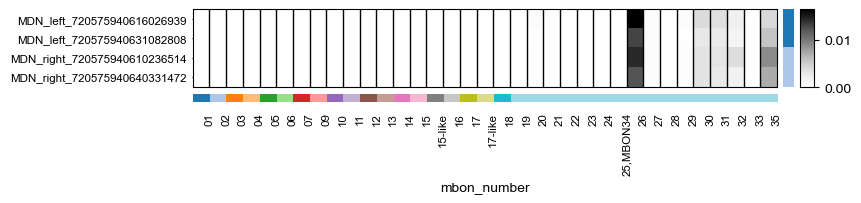

In [9]:
grouped_adata = ad.AnnData(grouped_influences['normalized_connections'][mdn_neurons_indices].T)
for mat_type, inf_mat in grouped_influences.items():
    if mat_type!='normalized_connections':
        continue
    grouped_adata.layers[mat_type] = inf_mat[mdn_neurons_indices].T
    

grouped_mbon_traced_neurons = mbon_traced_neurons.groupby('hemibrain_type').agg('mean').reset_index()#.set_index('hemibrain_type')
grouped_mbon_traced_neurons['name'] = grouped_mbon_traced_neurons.apply(lambda x: x['hemibrain_type'], axis=1)
grouped_mbon_traced_neurons = grouped_mbon_traced_neurons.set_index('name')

mdn_traced_neurons = traced_neurons[traced_neurons['idx'].isin(mdn_neurons_indices)].copy()
mdn_traced_neurons['name'] = mdn_traced_neurons.apply(lambda x: x['hemibrain_type'] + "_" + x['side'] + "_" + str(x['root_id']), axis=1)
mdn_traced_neurons = mdn_traced_neurons.set_index('name')

grouped_adata.var_names = mdn_traced_neurons.index
grouped_adata.obs_names = grouped_mbon_traced_neurons.index


grouped_adata.obs = grouped_mbon_traced_neurons
grouped_adata.obs['mbon_number'] = grouped_adata.obs['hemibrain_type'].apply(lambda x: x[4:])
grouped_adata.vars = mdn_traced_neurons
mdn_name_dict = {
    "Left MDN": ['MDN_left_720575940616026939', 'MDN_left_720575940631082808'],
    "Right MDN": ['MDN_right_720575940610236514', 'MDN_right_720575940640331472']}


layer = 'normalized_connections'
vmin = 0
vmax = np.max(grouped_adata.layers[layer])
cmap = 'Greys'
    
ax = sc.pl.heatmap(
    grouped_adata,
    mdn_name_dict,
    groupby='mbon_number',
    save= '2b.svg',
    layer=layer,
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    swap_axes=True,
    figsize=(11/96*len(grouped_adata.obs)*2, .65*2),
)

# Which intermediates are most influential?

This is calculated by looking at the two-step influence of MBONs on the MDNs and then removing each type of intermediate one at a time to see which ones have the biggest influence on the overall influence of MBONs on MDNs. It happens to be that the LALs are the most influential.

In [10]:
merged_connections = connections.merge(traced_neurons.reset_index(), left_on='pre_root_id', right_on='root_id', suffixes=['','__pre']).merge(traced_neurons.reset_index(), left_on='post_root_id', right_on='root_id', suffixes=['__pre','__post'])#.groupby(['cell_type__pre', 'cell_type__post', 'side__pre', 'side__post']).agg(sum)
to_mdn = merged_connections[(merged_connections.hemibrain_type__post=='MDN')]#.groupby(['hemibrain_type__pre', 'hemibrain_type__post', 'side__pre', 'side__post']).agg(sum)['weight'].reset_index()
from_mbon = merged_connections[ (merged_connections.hemibrain_type__pre.apply(lambda x: 'MBON' in str(x)))]#.isin(['MBON20', 'MBON26','MBON27', 'MBON30', 'MBON31', 'MBON32', 'MBON35']))]#.groupby(['hemibrain_type__pre', 'hemibrain_type__post', 'side__pre', 'side__post']).agg(sum)['weight'].reset_index()
to_mdn = to_mdn[to_mdn.pre_root_id.isin(from_mbon.post_root_id.unique())]
from_mbon = from_mbon[from_mbon.post_root_id.isin(to_mdn.pre_root_id.unique())]

In [11]:
intermediate_influences = {}
intermediate_of_interest = []
weight_mat_used = []
agg_mbon_vector = np.zeros((len(traced_neurons)))
agg_mbon_vector[mbon_indices] = 1

    
# for k,connection_screen in enumerate(connection_screens):
intermediate_influences= np.zeros((len(from_mbon.groupby(['hemibrain_type__post'])),len(connection_mats.keys())))
for j, (mat_name, weight_matrix_to_use) in enumerate(connection_mats.items()):
    weight_mat_used.append(mat_name)
    for i, (name, data) in enumerate(from_mbon.groupby(['hemibrain_type__post'])):
        if j ==0:
            intermediate_of_interest.append(name)
        screen = np.ones(weight_matrix_to_use.shape[0])
        screen[data.idx__post.unique()] = 0 # not controlling for how many neurons are removed each time, can do that but haven't
        
        intermediate_influences[i,j] = ((mdn_vec@weight_matrix_to_use@(weight_matrix_to_use@agg_mbon_vector)) - (mdn_vec@weight_matrix_to_use@diags(screen)@(weight_matrix_to_use@agg_mbon_vector)))


In [12]:
lals_of_interest = []
intermediate_df = pd.DataFrame(intermediate_influences, columns=weight_mat_used, index=intermediate_of_interest)
for m in weight_mat_used:
    # print(m)
    # display(intermediate_df[intermediate_df[m]!=0].sort_values(m,ascending=False, key=abs)[m])
    lals_of_interest.extend(intermediate_df[intermediate_df[m]!=0].sort_values(m,ascending=False, key=abs)[m][ :6].index)
    

Below are the LALs that are the top 6 most influential mediaries to MDN for each of the five weight matrices. Top 6 of any method (connection mat, signed connection mat, normalized connection mat, signed normailzed based on total or ei) yields the following intermediates:

LAL: 171,172, 051, 160,161, 008, 042, 162, 144, 040

In [13]:
lals_of_interest = pd.Series(lals_of_interest).unique()
print(lals_of_interest)

['LAL051' 'LAL171,LAL172' 'LAL160,LAL161' 'LAL144a' 'LAL040' 'LAL162'
 'LAL042' 'LAL008']


Two-step inputs to MDN come from te following MBONs:

In [14]:
from_mbon['hemibrain_type__pre'].unique()

array(['MBON32', 'MBON27', 'MBON26', 'MBON31', 'MBON30', 'MBON21',
       'MBON29', 'MBON35', 'MBON33', 'MBON20', 'MBON01', 'MBON25,MBON34',
       'MBON12', 'MBON05'], dtype=object)

# Which of the MBONs that make two step connections are the most influential (e.g. overall MBON --> MDN influence most impacted when removed)?

In [15]:
print('six most influential mbons are the same when calculated with normalized connections or connections')
mbon_types_of_interest = sorted(from_mbon[from_mbon!=0]['hemibrain_type__pre'].unique())
mbons_of_interest_vec = np.zeros((len(traced_neurons),len(mbon_types_of_interest)))
for i, m in enumerate(mbon_types_of_interest):
    idxs = mbon_traced_neurons[mbon_traced_neurons.hemibrain_type==m]['idx'].unique()
    mbons_of_interest_vec[idxs, i] = 1/len(idxs)

for mat_type, weight_matrix_to_use in connection_mats.items():
    if  'signed' in mat_type:
        continue
    if  mat_type =='normalized_connections':
        impactful_mbons_of_interest = list(filter( lambda x: x in np.array(mbon_types_of_interest)[(np.argsort(np.abs(mdn_vec@weight_matrix_to_use@(weight_matrix_to_use@mbons_of_interest_vec))))][-6:], mbon_types_of_interest))
    print(mat_type, np.sort(np.array(mbon_types_of_interest)[(np.argsort(np.abs(mdn_vec@weight_matrix_to_use@(weight_matrix_to_use@mbons_of_interest_vec))))][-6:]))
    


six most influential mbons are the same when calculated with normalized connections or connections
normalized_connections ['MBON26' 'MBON27' 'MBON30' 'MBON31' 'MBON32' 'MBON35']
connections ['MBON26' 'MBON27' 'MBON30' 'MBON31' 'MBON32' 'MBON35']


## Plot the percent of each top MBON's influence on MDN that is mediated by each of the top LALs

In [16]:
impactful_mbons_of_interest_vec = np.zeros((len(traced_neurons),len(impactful_mbons_of_interest)))
for i, m in enumerate(impactful_mbons_of_interest):
    idxs = mbon_traced_neurons[mbon_traced_neurons.hemibrain_type==m]['idx'].unique()
    impactful_mbons_of_interest_vec[idxs, i] = 1#/len(idxs)

In [17]:

merged_connections = connections.merge(traced_neurons.reset_index(), left_on='pre_root_id', right_on='root_id', suffixes=['','__pre']).merge(traced_neurons.reset_index(), left_on='post_root_id', right_on='root_id', suffixes=['__pre','__post'])#.groupby(['cell_type__pre', 'cell_type__post', 'side__pre', 'side__post']).agg(sum)
to_mdn = merged_connections[(merged_connections.hemibrain_type__post=='MDN')]#.groupby(['hemibrain_type__pre', 'hemibrain_type__post', 'side__pre', 'side__post']).agg(sum)['weight'].reset_index()
from_mbon = merged_connections[ (merged_connections.hemibrain_type__pre.isin(impactful_mbons_of_interest))]#.isin(['MBON20', 'MBON26','MBON27', 'MBON30', 'MBON31', 'MBON32', 'MBON35']))]#.groupby(['hemibrain_type__pre', 'hemibrain_type__post', 'side__pre', 'side__post']).agg(sum)['weight'].reset_index()
to_mdn = to_mdn[to_mdn.pre_root_id.isin(from_mbon.post_root_id.unique())]
from_mbon = from_mbon[from_mbon.post_root_id.isin(to_mdn.pre_root_id.unique())]

In [18]:

weight_matrix_to_use = connection_mats['normalized_connections']
intermediate_influences = np.zeros((len(from_mbon.groupby(['hemibrain_type__post'])), len(impactful_mbons_of_interest)))
intermediate_of_interest = []
for i, (name, data) in enumerate(from_mbon.groupby(['hemibrain_type__post'])):
    intermediate_of_interest.append(name)
    screen = np.ones(weight_matrix_to_use.shape[0])
    screen[data.idx__post.unique()] = 0 # not controlling for how many neurons are removed each time, can do that but haven't
    screened_weight_matrix = diags(screen)@weight_matrix_to_use@diags(screen)

    tot_mat = (mdn_vec@weight_matrix_to_use@(weight_matrix_to_use@impactful_mbons_of_interest_vec))
    intermediate_influences[i] = (tot_mat - (mdn_vec@weight_matrix_to_use@diags(screen)@(weight_matrix_to_use@impactful_mbons_of_interest_vec)))/tot_mat
intermediate_df = pd.DataFrame(intermediate_influences, columns=impactful_mbons_of_interest, index=intermediate_of_interest)
intermediate_df['lal_name'] = list(intermediate_df.index)
intermediate_df.loc['Other intermediaries'] = np.sum(intermediate_df[intermediate_df['lal_name'].apply(lambda x: x not in lals_of_interest)])
intermediate_df['lal_name'] = intermediate_df.index
intermediate_df=intermediate_df[intermediate_df['lal_name'].apply(lambda x: x in list(lals_of_interest) + ['Other intermediaries'])].drop(columns='lal_name')





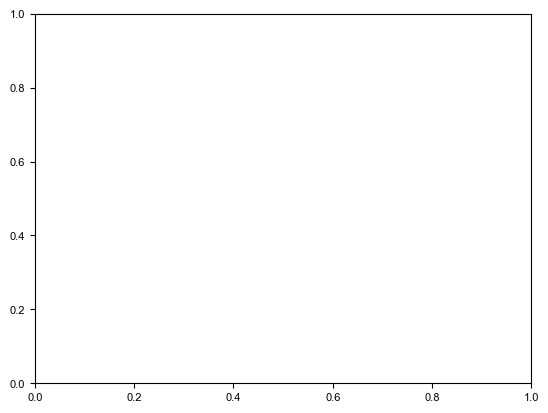

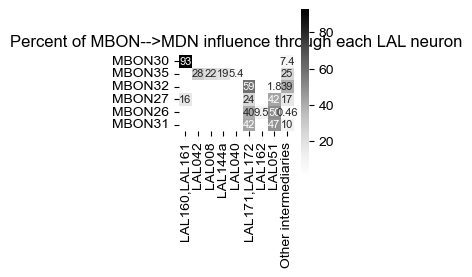

In [19]:
mbon_order = ['MBON30','MBON35','MBON32','MBON27','MBON26','MBON31']
lal_order = ['LAL160,LAL161','LAL042', 'LAL008', 'LAL144a','LAL040','LAL171,LAL172','LAL162','LAL051', 'Other intermediaries']

intermediate_df = intermediate_df.loc[lal_order,mbon_order]


cmap = plt.cm.get_cmap('Greys').copy()
cmap.set_bad('white')
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.figure(figsize=(1.85,2.17))
sns.heatmap(intermediate_df.T*100, square=True, annot=True,mask=intermediate_df.T==0, cmap=cmap, annot_kws={"size": 8}, xticklabels=1,yticklabels=1)

plt.title('Percent of MBON-->MDN influence through each LAL neuron')
plt.savefig("./results/2d.svg", bbox_inches='tight')

## Save out LAL root IDs for synaptic site plotting

In [20]:
traced_neurons[traced_neurons['hemibrain_type'].isin(lals_of_interest)].astype('str').to_excel('./results/'+data_path.split('/')[-2] + '_LALrootIDsFor2e.xlsx')

## Create csv with information for Figure 2c
normalized connection and # synapses for each MBON type to LAL type and LAL type to MDN type

In [21]:
type_to_count = dict(traced_neurons.groupby('hemibrain_type').agg('count')['bodyId'])
grouped_from_mbon = from_mbon[ from_mbon['hemibrain_type__pre'].isin(impactful_mbons_of_interest) & from_mbon['hemibrain_type__post'].isin(lals_of_interest)].groupby(['hemibrain_type__pre', 'hemibrain_type__post']).agg('sum')

filtered_normalized_from_mbon = from_mbon[from_mbon['hemibrain_type__pre'].isin(impactful_mbons_of_interest) & from_mbon['hemibrain_type__post'].isin(lals_of_interest)].groupby(['hemibrain_type__pre', 'root_id__post', 'hemibrain_type__post']).agg('sum').reset_index()
filtered_normalized_from_mbon['total_possible_post_type_neurons'] = filtered_normalized_from_mbon.apply(lambda x: type_to_count[x.hemibrain_type__post] ,axis=1)
filtered_normalized_from_mbon['normalized_weights'] = filtered_normalized_from_mbon['normalized_weights']/filtered_normalized_from_mbon['total_possible_post_type_neurons']*100
filtered_normalized_from_mbon = filtered_normalized_from_mbon.groupby(['hemibrain_type__pre', 'hemibrain_type__post']).agg('sum').reset_index()

grouped_to_mdn = to_mdn[ to_mdn['hemibrain_type__pre'].isin(lals_of_interest) ].groupby(['hemibrain_type__pre', 'hemibrain_type__post']).agg('sum')

filtered_normalized_to_mdn = to_mdn[to_mdn['hemibrain_type__pre'].isin(lals_of_interest)].groupby(['hemibrain_type__pre', 'root_id__post', 'hemibrain_type__post']).agg('sum').reset_index()
filtered_normalized_to_mdn['total_post_type_neurons'] = filtered_normalized_to_mdn.apply(lambda x: type_to_count[x.hemibrain_type__post] ,axis=1)
filtered_normalized_to_mdn['normalized_weights'] = filtered_normalized_to_mdn['normalized_weights']/filtered_normalized_to_mdn['total_post_type_neurons']*100
filtered_normalized_to_mdn = filtered_normalized_to_mdn.groupby(['hemibrain_type__pre', 'hemibrain_type__post']).agg('sum').reset_index()

filtered_normalized_from_mbon[['hemibrain_type__pre', 'hemibrain_type__post','normalized_weights']
                              ].merge(grouped_from_mbon.reset_index()[grouped_from_mbon.reset_index()['weight']>=20][['hemibrain_type__pre', 'hemibrain_type__post','weight']], on=['hemibrain_type__post', 'hemibrain_type__pre'],how='inner'
                                      ).append(filtered_normalized_to_mdn[['hemibrain_type__pre', 'hemibrain_type__post','normalized_weights']
                                                                          ].merge(grouped_to_mdn.reset_index()[grouped_to_mdn.reset_index()['weight']>=20][['hemibrain_type__pre', 'hemibrain_type__post','weight']], on=['hemibrain_type__post', 'hemibrain_type__pre'],how='inner')
                                              ).to_csv('./results/2c-connections-and-percent-input.csv')

/var/folders/tt/z91kvz8d6jj096mmy336sdz80000gn/T/ipykernel_26381/3442251487.py:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  ).append(filtered_normalized_to_mdn[['hemibrain_type__pre', 'hemibrain_type__post','normalized_weights']


## MDN to DAN

MDN to DAN connections are 3+ steps and weak.

In [22]:
normalized_connections_mat=connection_mats['normalized_connections']

dans_traced = traced_neurons[traced_neurons.hemibrain_type.apply(lambda x: 'PAM' in str(x) or 'PPL' in str(x))]
dan_vec = np.zeros((len(traced_neurons), len(dans_traced.idx.unique())))
dan_vec[dans_traced.idx.unique(), range(len(dans_traced.idx.unique()))] =1
dan_vec = dan_vec.T

n_steps =10
input_vec = mdn_vec*4
for i in range(n_steps):
    input_vec = normalized_connections_mat@input_vec
    print("The max percentage of input a DAN receives from MDN after", i+1, "steps is", np.max(dan_vec@input_vec)*100, "%")


The max percentage of input a DAN receives from MDN after 1 steps is 0.0 %
The max percentage of input a DAN receives from MDN after 2 steps is 0.0 %
The max percentage of input a DAN receives from MDN after 3 steps is 0.0008426486244128038 %
The max percentage of input a DAN receives from MDN after 4 steps is 0.0036359158961949503 %
The max percentage of input a DAN receives from MDN after 5 steps is 0.002241392790417599 %
The max percentage of input a DAN receives from MDN after 6 steps is 0.0018735425402462012 %
The max percentage of input a DAN receives from MDN after 7 steps is 0.0020432963327580967 %
The max percentage of input a DAN receives from MDN after 8 steps is 0.001386333479316518 %
The max percentage of input a DAN receives from MDN after 9 steps is 0.0020387624388216144 %
The max percentage of input a DAN receives from MDN after 10 steps is 0.0015647861434750384 %
